In [43]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import casadi as ca
import cyecca.lie as lie
import numpy as np

from eqf.equivariant_filter_casadi import EqFProblem, derive_equivariant_filter

In [44]:
G = lie.SE3Quat

# State xi = (R, b) is embedded as a 4x4 matrix [R b; 0 1].
# Group X = (A, a) is represented in cyecca's native SE3Quat coordinates:
# X = [a_x, a_y, a_z, q_w, q_x, q_y, q_z].  Avoid 4x4 group matrices here
# because SE3Quat.from_Matrix is not implemented in cyecca.
X_hat = ca.SX.sym("X_hat", 7)
xi = ca.SX.sym("xi", 4, 4)
Omega = ca.SX.sym("Omega", 3)
eps = ca.SX.sym("eps", 6)  # eps = [attitude_error, bias_error]
y = ca.SX.sym("y", 6)

# Known inertial reference directions for accelerometer/gravity and magnetometer.
d1 = ca.SX.sym("d1", 3)
d2 = ca.SX.sym("d2", 3)
I4 = ca.SX.eye(4)


def state_rotation(T):
    return T[0:3, 0:3]


def state_bias(T):
    return T[0:3, 3]


def group_rotation(X):
    return G.elem(X).R.to_Matrix()


def group_vector(X):
    return G.elem(X).p.param


def make_state_matrix(R, b):
    return ca.vertcat(
        ca.horzcat(R, b),
        ca.horzcat(ca.SX.zeros(1, 3), ca.SX.ones(1, 1)),
    )


def state_action(X, state):
    A = group_rotation(X)
    a = group_vector(X)
    R = state_rotation(state)
    b = state_bias(state)
    return make_state_matrix(R @ A, A.T @ (b - a))


def input_action(X, omega):
    A = group_rotation(X)
    a = group_vector(X)
    return A.T @ (omega - a)


def output(state):
    R = state_rotation(state)
    return ca.vertcat(R.T @ d1, R.T @ d2)


def output_action(X, measurement):
    A = group_rotation(X)
    y1 = measurement[0:3]
    y2 = measurement[3:6]
    return ca.vertcat(A.T @ y1, A.T @ y2)


def lift(state, omega):
    b = state_bias(state)
    omega_corrected = omega - b
    beta = -ca.cross(omega, b)
    # cyecca SE3 algebra coordinates are [translation, rotation].
    return ca.vertcat(beta, omega_corrected)


def chart_inv(error):
    R_error = lie.so3.elem(error[0:3]).exp(lie.SO3Dcm).to_Matrix()
    b_error = error[3:6]
    return make_state_matrix(R_error, b_error)


def algebra_from_error(error):
    # Local coordinates are [attitude, bias], while SE3 algebra is [translation, rotation].
    return ca.vertcat(-error[3:6], error[0:3])


attitude_bias_problem = EqFProblem(
    name="attitude_bias_eqf",
    state=xi,
    group=X_hat,
    input=Omega,
    error=eps,
    output_measurement=y,
    lie_group=G,
    origin=I4,
    parameters=(d1, d2),
    action=state_action,
    input_action=input_action,
    output=output,
    output_action=output_action,
    lift=lift,
    chart_inv=chart_inv,
    algebra_from_error=algebra_from_error,
)

attitude_bias_derived = derive_equivariant_filter(attitude_bias_problem)

X_hat_num = np.array([0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0])
Omega_num = np.zeros(3)
y_num = np.array([0.0, 0.0, -1.0, 0.2, 0.05, 0.45])
d1_num = np.array([0.0, 0.0, -1.0])
d2_num = np.array([0.2, 0.05, 0.45])

print("A =\n", np.array(attitude_bias_derived.A(X_hat_num, Omega_num, d1_num, d2_num), dtype=float))
print("B =\n", np.array(attitude_bias_derived.B(X_hat_num, Omega_num, d1_num, d2_num), dtype=float))
print("C =\n", np.array(attitude_bias_derived.C(X_hat_num, d1_num, d2_num), dtype=float))
print("C* =\n", np.array(attitude_bias_derived.C_star(X_hat_num, y_num, d1_num, d2_num), dtype=float))

A =
 [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 -1.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  -1.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.57009246e-16 -1.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  -0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00 -0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 -0.00000000e+00
   0.00000000e+00  0.00000000e+00]]
B =
 [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00 -1.57009246e-16  1.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]
C =
 [[-0.    1.    0.    0.    0.    0.  ]
 [-1.    0.    0.    0.    0.   

Running 100 Monte Carlo trials...
  trial 1/100
  trial 5/100
  trial 10/100
  trial 15/100
  trial 20/100
  trial 25/100
  trial 30/100
  trial 35/100
  trial 40/100
  trial 45/100
  trial 50/100
  trial 55/100
  trial 60/100
  trial 65/100
  trial 70/100
  trial 75/100
  trial 80/100
  trial 85/100
  trial 90/100
  trial 95/100
  trial 100/100
Monte Carlo trials complete.


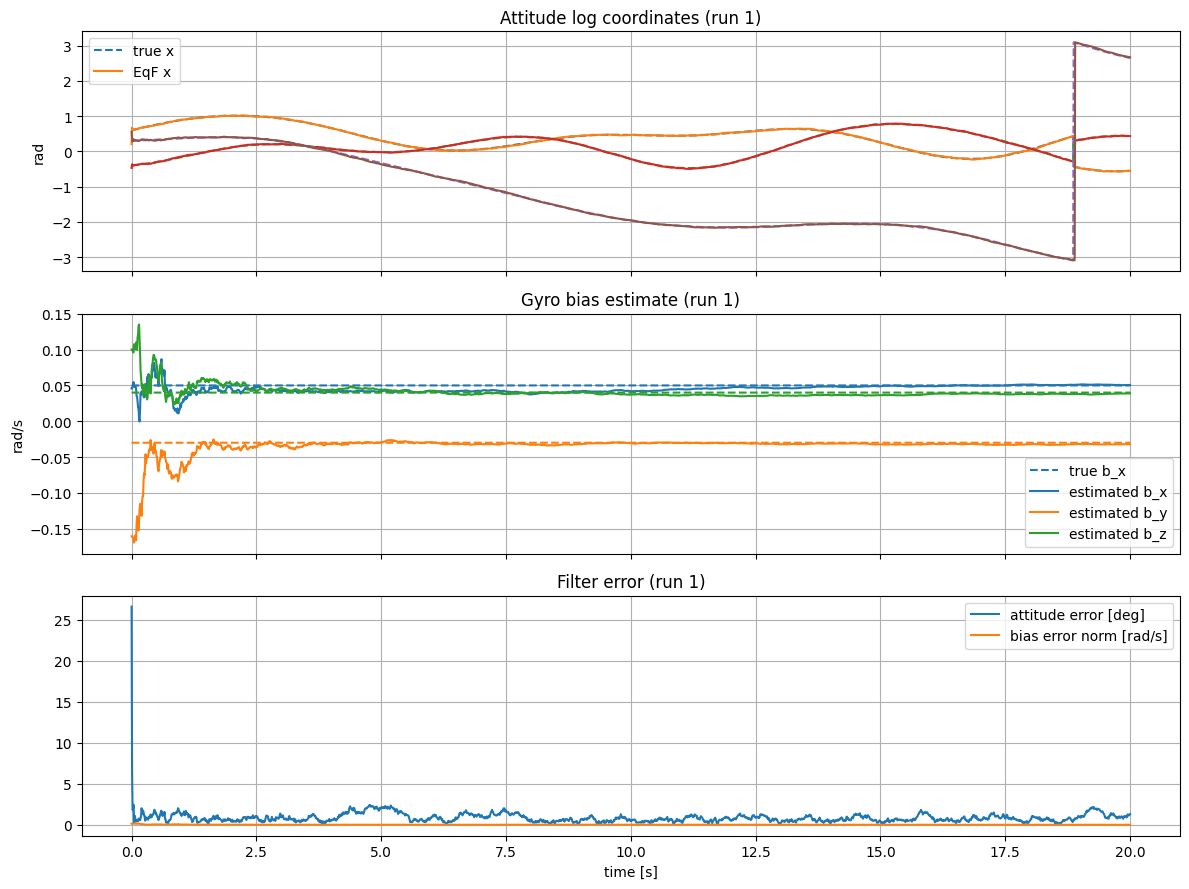

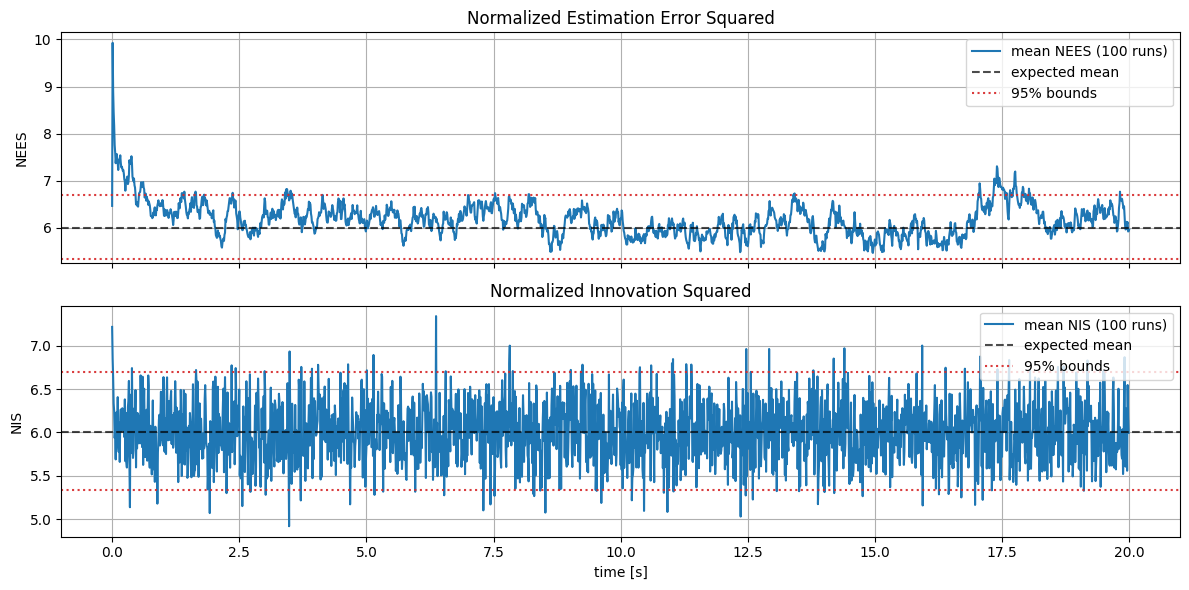

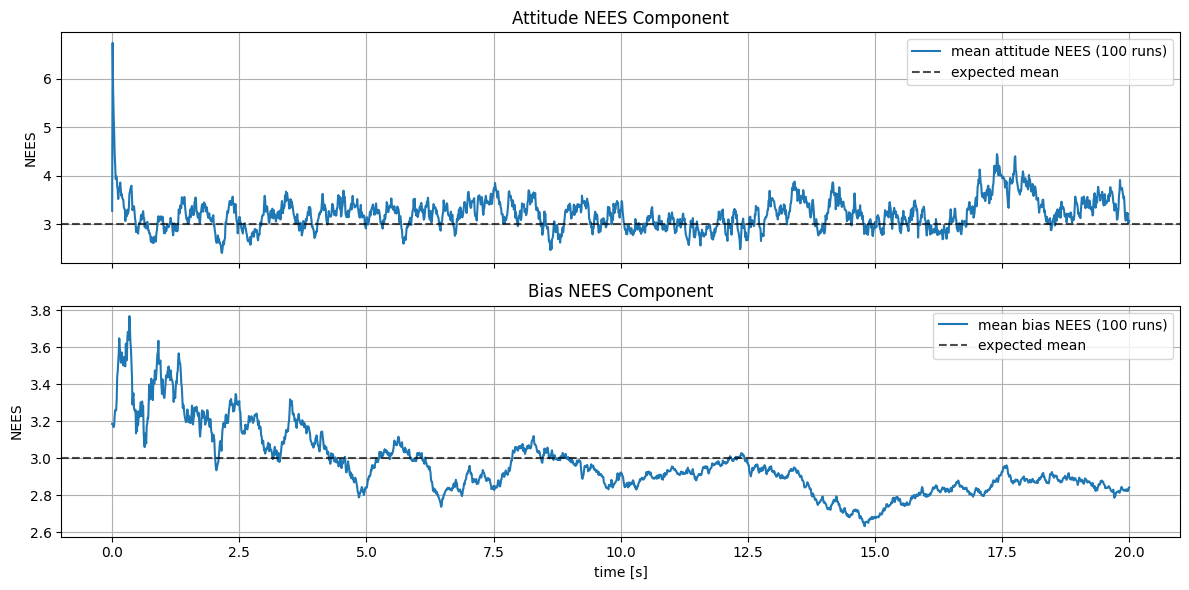

Mean NEES: 6.187 (expected near 6, 95% bounds [5.340, 6.698])
Mean attitude NEES: 3.216 (expected near 3)
Mean bias NEES: 2.964 (expected near 3)
Mean NIS: 6.010 (expected near 6, 95% bounds [5.340, 6.698])
Minimum posterior covariance eigenvalue over all runs: 1.149e-05


In [45]:
import matplotlib.pyplot as plt


def hat(v):
    v = np.asarray(v, dtype=float).reshape(3)
    return np.array(
        [
            [0.0, -v[2], v[1]],
            [v[2], 0.0, -v[0]],
            [-v[1], v[0], 0.0],
        ]
    )


def exp_so3(phi):
    phi = np.asarray(phi, dtype=float).reshape(3)
    theta = np.linalg.norm(phi)
    K = hat(phi)
    if theta < 1e-9:
        return np.eye(3) + K + 0.5 * K @ K
    return np.eye(3) + np.sin(theta) / theta * K + (1.0 - np.cos(theta)) / theta**2 * K @ K


def log_so3(R):
    R = np.asarray(R, dtype=float).reshape(3, 3)
    c = np.clip((np.trace(R) - 1.0) / 2.0, -1.0, 1.0)
    theta = np.arccos(c)
    if theta < 1e-9:
        return np.array([R[2, 1] - R[1, 2], R[0, 2] - R[2, 0], R[1, 0] - R[0, 1]]) / 2.0
    return theta / (2.0 * np.sin(theta)) * np.array(
        [R[2, 1] - R[1, 2], R[0, 2] - R[2, 0], R[1, 0] - R[0, 1]]
    )


def left_jacobian_so3(phi):
    phi = np.asarray(phi, dtype=float).reshape(3)
    theta = np.linalg.norm(phi)
    K = hat(phi)
    if theta < 1e-9:
        return np.eye(3) + 0.5 * K + (1.0 / 6.0) * K @ K
    return np.eye(3) + (1.0 - np.cos(theta)) / theta**2 * K + (theta - np.sin(theta)) / theta**3 * K @ K


def exp_se3(beta, omega):
    omega = np.asarray(omega, dtype=float).reshape(3)
    beta = np.asarray(beta, dtype=float).reshape(3)
    X = np.eye(4)
    X[0:3, 0:3] = exp_so3(omega)
    X[0:3, 3] = left_jacobian_so3(omega) @ beta
    return X


def project_to_so3(R):
    U, _, Vt = np.linalg.svd(R)
    R_proj = U @ Vt
    if np.linalg.det(R_proj) < 0.0:
        U[:, -1] *= -1.0
        R_proj = U @ Vt
    return R_proj


def rotation_to_quat_wxyz(R):
    R = project_to_so3(R)
    tr = np.trace(R)
    if tr > 0.0:
        s = np.sqrt(tr + 1.0) * 2.0
        return np.array([0.25 * s, (R[2, 1] - R[1, 2]) / s, (R[0, 2] - R[2, 0]) / s, (R[1, 0] - R[0, 1]) / s])
    if R[0, 0] > R[1, 1] and R[0, 0] > R[2, 2]:
        s = np.sqrt(1.0 + R[0, 0] - R[1, 1] - R[2, 2]) * 2.0
        return np.array([(R[2, 1] - R[1, 2]) / s, 0.25 * s, (R[0, 1] + R[1, 0]) / s, (R[0, 2] + R[2, 0]) / s])
    if R[1, 1] > R[2, 2]:
        s = np.sqrt(1.0 + R[1, 1] - R[0, 0] - R[2, 2]) * 2.0
        return np.array([(R[0, 2] - R[2, 0]) / s, (R[0, 1] + R[1, 0]) / s, 0.25 * s, (R[1, 2] + R[2, 1]) / s])
    s = np.sqrt(1.0 + R[2, 2] - R[0, 0] - R[1, 1]) * 2.0
    return np.array([(R[1, 0] - R[0, 1]) / s, (R[0, 2] + R[2, 0]) / s, (R[1, 2] + R[2, 1]) / s, 0.25 * s])


def matrix_to_group_params(X):
    return np.concatenate((X[0:3, 3], rotation_to_quat_wxyz(X[0:3, 0:3])))


def symmetrize_psd(P, floor=1e-10):
    P = 0.5 * (P + P.T)
    vals, vecs = np.linalg.eigh(P)
    return vecs @ np.diag(np.maximum(vals, floor)) @ vecs.T


def normalize(v):
    v = np.asarray(v, dtype=float).reshape(3)
    n = np.linalg.norm(v)
    return v if n < 1e-12 else v / n


def pack_group(R_hat, b_hat):
    X = np.eye(4)
    X[0:3, 0:3] = R_hat
    X[0:3, 3] = -R_hat @ b_hat
    return X


def unpack_estimate(X_hat):
    R_hat = project_to_so3(X_hat[0:3, 0:3])
    a_hat = X_hat[0:3, 3]
    b_hat = -R_hat.T @ a_hat
    return R_hat, b_hat


def omega_true_profile(t):
    return np.array(
        [
            0.35 * np.cos(0.7 * t),
            0.25 * np.sin(1.1 * t + 0.3),
            -0.20 + 0.15 * np.cos(0.5 * t),
        ]
    )


def EqF_step(X_hat, P, omega_meas, y_meas, dt, d1_num, d2_num, M_c, R_meas):
    R_hat, b_hat = unpack_estimate(X_hat)

    omega_corrected = omega_meas - b_hat
    beta = -np.cross(omega_meas, b_hat)
    X_hat = X_hat @ exp_se3(beta * dt, omega_corrected * dt)
    X_hat[0:3, 0:3] = project_to_so3(X_hat[0:3, 0:3])

    X_hat_params = matrix_to_group_params(X_hat)
    A = np.array(attitude_bias_derived.A(X_hat_params, omega_meas, d1_num, d2_num), dtype=float)
    Phi = np.eye(6) + A * dt
    P = symmetrize_psd(Phi @ P @ Phi.T + M_c * dt)

    R_hat, _ = unpack_estimate(X_hat)
    yhat = np.concatenate((R_hat.T @ d1_num, R_hat.T @ d2_num))
    innovation = y_meas - yhat

    C = np.array(attitude_bias_derived.C_star(X_hat_params, y_meas, d1_num, d2_num), dtype=float)
    S = C @ P @ C.T + R_meas
    K = P @ C.T @ np.linalg.solve(S, np.eye(S.shape[0]))
    delta = K @ innovation

    # EqF correction: local coordinates are [attitude, bias], SE3 algebra is [translation, rotation].
    X_hat = exp_se3(-delta[3:6], delta[0:3]) @ X_hat
    X_hat[0:3, 0:3] = project_to_so3(X_hat[0:3, 0:3])
    P = symmetrize_psd((np.eye(6) - K @ C) @ P @ (np.eye(6) - K @ C).T + K @ R_meas @ K.T)
    return X_hat, P, innovation, S


def state_error(R_true, R_hat, b_true, b_hat):
    attitude_error = log_so3(R_true @ R_hat.T)
    bias_error = R_hat @ (b_true - b_hat)
    return np.concatenate((attitude_error, bias_error))


def quadratic_form(value, covariance):
    value = np.asarray(value, dtype=float).reshape(-1)
    covariance = symmetrize_psd(np.asarray(covariance, dtype=float))
    return float(value.T @ np.linalg.solve(covariance, value))


dt = 0.01
T = 20.0
n_steps = int(T / dt)
times = np.arange(n_steps + 1) * dt
n_monte_carlo = 100

# Inertial reference directions measured in the body frame.
d1_num = normalize(np.array([0.0, 0.0, -1.0]))
d2_num = normalize(np.array([0.2, 0.05, 0.45]))

b_true0 = np.array([0.05, -0.03, 0.04])
sigma_gyro = 0.015  # Continuous-time gyro noise density [rad/sqrt(s)].
sigma_bias = 0.0  # Constant true bias; no bias random-walk process noise.
sigma_y = 0.035  # Discrete-time direction-vector measurement standard deviation.
Q_gyro_c = (sigma_gyro**2) * np.eye(3)
Q_bias_c = (sigma_bias**2) * np.eye(3)
M_c = np.block(
    [
        [Q_gyro_c, np.zeros((3, 3))],
        [np.zeros((3, 3)), Q_bias_c],
    ]
)
R_meas = (sigma_y**2) * np.eye(6)

R_true0 = exp_so3(np.array([0.6, -0.4, 0.3]))
R_hat0 = exp_so3(np.array([0.2, -0.1, -0.2]))
b_hat0 = np.zeros(3)
P0 = np.diag([0.4, 0.4, 0.4, 0.08, 0.08, 0.08]) ** 2

state_dof = 6
measurement_dof = 6


def chi_square_bounds(dof, sample_count=1, confidence=0.95):
    alpha = 1.0 - confidence
    total_dof = sample_count * dof
    try:
        from scipy.stats import chi2

        lower = chi2.ppf(alpha / 2.0, total_dof) / sample_count
        upper = chi2.ppf(1.0 - alpha / 2.0, total_dof) / sample_count
    except ImportError:
        from statistics import NormalDist

        # Wilson-Hilferty approximation, used only if scipy is unavailable.
        z_lower = NormalDist().inv_cdf(alpha / 2.0)
        z_upper = NormalDist().inv_cdf(1.0 - alpha / 2.0)
        lower = total_dof * (1.0 - 2.0 / (9.0 * total_dof) + z_lower * np.sqrt(2.0 / (9.0 * total_dof))) ** 3
        upper = total_dof * (1.0 - 2.0 / (9.0 * total_dof) + z_upper * np.sqrt(2.0 / (9.0 * total_dof))) ** 3
        lower /= sample_count
        upper /= sample_count
    return lower, upper


def sample_initial_estimate(rng):
    initial_error = rng.multivariate_normal(np.zeros(state_dof), P0)
    R_hat = project_to_so3(exp_so3(-initial_error[0:3]) @ R_true0)
    b_hat = b_true0 - R_hat.T @ initial_error[3:6]
    return pack_group(R_hat, b_hat)


def run_filter_trial(seed, keep_history=False):
    rng = np.random.default_rng(seed)
    R_true = R_true0.copy()
    b_true = b_true0.copy()
    X_hat = sample_initial_estimate(rng)
    P = P0.copy()
    min_cov_eig = np.linalg.eigvalsh(P).min()

    nees_hist = np.zeros(n_steps + 1)
    nis_hist = np.zeros(n_steps)
    nees_att_hist = np.zeros(n_steps + 1)
    nees_bias_hist = np.zeros(n_steps + 1)

    R_hat, b_hat = unpack_estimate(X_hat)
    initial_error = state_error(R_true, R_hat, b_true, b_hat)
    nees_hist[0] = quadratic_form(initial_error, P)
    nees_att_hist[0] = quadratic_form(initial_error[0:3], P[0:3, 0:3])
    nees_bias_hist[0] = quadratic_form(initial_error[3:6], P[3:6, 3:6])

    history = None
    if keep_history:
        history = {
            "rot_true": np.zeros((n_steps + 1, 3)),
            "rot_hat": np.zeros((n_steps + 1, 3)),
            "b_true": np.zeros((n_steps + 1, 3)),
            "b_hat": np.zeros((n_steps + 1, 3)),
            "omega_true": np.zeros((n_steps, 3)),
            "omega_est": np.zeros((n_steps, 3)),
            "att_err": np.zeros(n_steps + 1),
            "bias_err": np.zeros(n_steps + 1),
        }
        history["rot_true"][0] = log_so3(R_true)
        history["rot_hat"][0] = log_so3(R_hat)
        history["b_true"][0] = b_true
        history["b_hat"][0] = b_hat
        history["att_err"][0] = np.degrees(np.linalg.norm(initial_error[0:3]))
        history["bias_err"][0] = np.linalg.norm(initial_error[3:6])

    for k, t in enumerate(times[:-1]):
        omega_true = omega_true_profile(t)
        omega_meas = omega_true + b_true + (sigma_gyro / np.sqrt(dt)) * rng.standard_normal(3)

        y_true = np.concatenate((R_true.T @ d1_num, R_true.T @ d2_num))
        y_meas = y_true + sigma_y * rng.standard_normal(6)

        X_hat, P, innovation, S = EqF_step(X_hat, P, omega_meas, y_meas, dt, d1_num, d2_num, M_c, R_meas)
        R_hat, b_hat = unpack_estimate(X_hat)
        min_cov_eig = min(min_cov_eig, np.linalg.eigvalsh(P).min())

        R_true = project_to_so3(R_true @ exp_so3(omega_true * dt))
        error = state_error(R_true, R_hat, b_true, b_hat)

        nees_hist[k + 1] = quadratic_form(error, P)
        nis_hist[k] = quadratic_form(innovation, S)
        nees_att_hist[k + 1] = quadratic_form(error[0:3], P[0:3, 0:3])
        nees_bias_hist[k + 1] = quadratic_form(error[3:6], P[3:6, 3:6])

        if keep_history:
            history["rot_true"][k + 1] = log_so3(R_true)
            history["rot_hat"][k + 1] = log_so3(R_hat)
            history["b_true"][k + 1] = b_true
            history["b_hat"][k + 1] = b_hat
            history["omega_true"][k] = omega_true
            history["omega_est"][k] = omega_meas - b_hat
            history["att_err"][k + 1] = np.degrees(np.linalg.norm(error[0:3]))
            history["bias_err"][k + 1] = np.linalg.norm(error[3:6])

    return nees_hist, nis_hist, nees_att_hist, nees_bias_hist, min_cov_eig, history


nees_mc = np.zeros((n_monte_carlo, n_steps + 1))
nis_mc = np.zeros((n_monte_carlo, n_steps))
nees_att_mc = np.zeros((n_monte_carlo, n_steps + 1))
nees_bias_mc = np.zeros((n_monte_carlo, n_steps + 1))
min_cov_eigs = np.zeros(n_monte_carlo)
representative_history = None

print(f"Running {n_monte_carlo} Monte Carlo trials...")
for run_idx in range(n_monte_carlo):
    if run_idx == 0 or (run_idx + 1) % 5 == 0 or run_idx + 1 == n_monte_carlo:
        print(f"  trial {run_idx + 1}/{n_monte_carlo}", flush=True)
    nees_hist, nis_hist, nees_att_hist, nees_bias_hist, min_cov_eig, history = run_filter_trial(
        67676767 + run_idx,
        keep_history=(run_idx == 0),
    )
    nees_mc[run_idx] = nees_hist
    nis_mc[run_idx] = nis_hist
    nees_att_mc[run_idx] = nees_att_hist
    nees_bias_mc[run_idx] = nees_bias_hist
    min_cov_eigs[run_idx] = min_cov_eig
    if history is not None:
        representative_history = history
print("Monte Carlo trials complete.")

rot_true_hist = representative_history["rot_true"]
rot_hat_hist = representative_history["rot_hat"]
b_true_hist = representative_history["b_true"]
b_hat_hist = representative_history["b_hat"]
att_err_hist = representative_history["att_err"]
bias_err_hist = representative_history["bias_err"]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
labels = ["x", "y", "z"]

for i, label in enumerate(labels):
    axes[0].plot(times, rot_true_hist[:, i], "--", label=f"true {label}" if i == 0 else None)
    axes[0].plot(times, rot_hat_hist[:, i], label=f"EqF {label}" if i == 0 else None)
axes[0].set_title("Attitude log coordinates (run 1)")
axes[0].set_ylabel("rad")
axes[0].grid(True)
axes[0].legend()

for i, label in enumerate(labels):
    axes[1].plot(times, b_true_hist[:, i], "--", color=f"C{i}", label=f"true b_{label}" if i == 0 else None)
    axes[1].plot(times, b_hat_hist[:, i], color=f"C{i}", label=f"estimated b_{label}")
axes[1].set_title("Gyro bias estimate (run 1)")
axes[1].set_ylabel("rad/s")
axes[1].grid(True)
axes[1].legend()

axes[2].plot(times, att_err_hist, label="attitude error [deg]")
axes[2].plot(times, bias_err_hist, label="bias error norm [rad/s]")
axes[2].set_title("Filter error (run 1)")
axes[2].set_xlabel("time [s]")
axes[2].grid(True)
axes[2].legend()

fig.tight_layout()
plt.show()

mean_nees = np.mean(nees_mc, axis=0)
mean_nis = np.mean(nis_mc, axis=0)
mean_nees_att = np.mean(nees_att_mc, axis=0)
mean_nees_bias = np.mean(nees_bias_mc, axis=0)
nees_lower, nees_upper = chi_square_bounds(state_dof, sample_count=n_monte_carlo)
nis_lower, nis_upper = chi_square_bounds(measurement_dof, sample_count=n_monte_carlo)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(times, mean_nees, label=f"mean NEES ({n_monte_carlo} runs)")
axes[0].axhline(state_dof, color="k", linestyle="--", alpha=0.7, label="expected mean")
axes[0].axhline(nees_lower, color="C3", linestyle=":", alpha=0.9, label="95% bounds")
axes[0].axhline(nees_upper, color="C3", linestyle=":", alpha=0.9)
axes[0].set_title("Normalized Estimation Error Squared")
axes[0].set_ylabel("NEES")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(times[:-1], mean_nis, label=f"mean NIS ({n_monte_carlo} runs)")
axes[1].axhline(measurement_dof, color="k", linestyle="--", alpha=0.7, label="expected mean")
axes[1].axhline(nis_lower, color="C3", linestyle=":", alpha=0.9, label="95% bounds")
axes[1].axhline(nis_upper, color="C3", linestyle=":", alpha=0.9)
axes[1].set_title("Normalized Innovation Squared")
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("NIS")
axes[1].grid(True)
axes[1].legend()

fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(times, mean_nees_att, label=f"mean attitude NEES ({n_monte_carlo} runs)")
axes[0].axhline(3, color="k", linestyle="--", alpha=0.7, label="expected mean")
axes[0].set_title("Attitude NEES Component")
axes[0].set_ylabel("NEES")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(times, mean_nees_bias, label=f"mean bias NEES ({n_monte_carlo} runs)")
axes[1].axhline(3, color="k", linestyle="--", alpha=0.7, label="expected mean")
axes[1].set_title("Bias NEES Component")
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("NEES")
axes[1].grid(True)
axes[1].legend()

fig.tight_layout()
plt.show()

print(f"Mean NEES: {np.mean(mean_nees):.3f} (expected near {state_dof}, 95% bounds [{nees_lower:.3f}, {nees_upper:.3f}])")
print(f"Mean attitude NEES: {np.mean(mean_nees_att):.3f} (expected near 3)")
print(f"Mean bias NEES: {np.mean(mean_nees_bias):.3f} (expected near 3)")
print(f"Mean NIS: {np.mean(mean_nis):.3f} (expected near {measurement_dof}, 95% bounds [{nis_lower:.3f}, {nis_upper:.3f}])")
print(f"Minimum posterior covariance eigenvalue over all runs: {np.min(min_cov_eigs):.3e}")